In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import QuantileTransformer

In [15]:
df = pd.read_csv('./data/titanic_clean.csv')
df.sample(4)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
722,0,2,male,34.0,0,0,13.000,S
804,1,3,male,27.0,0,0,6.975,S
770,0,3,male,24.0,0,0,9.500,S
842,1,1,female,30.0,0,0,31.000,C


In [16]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

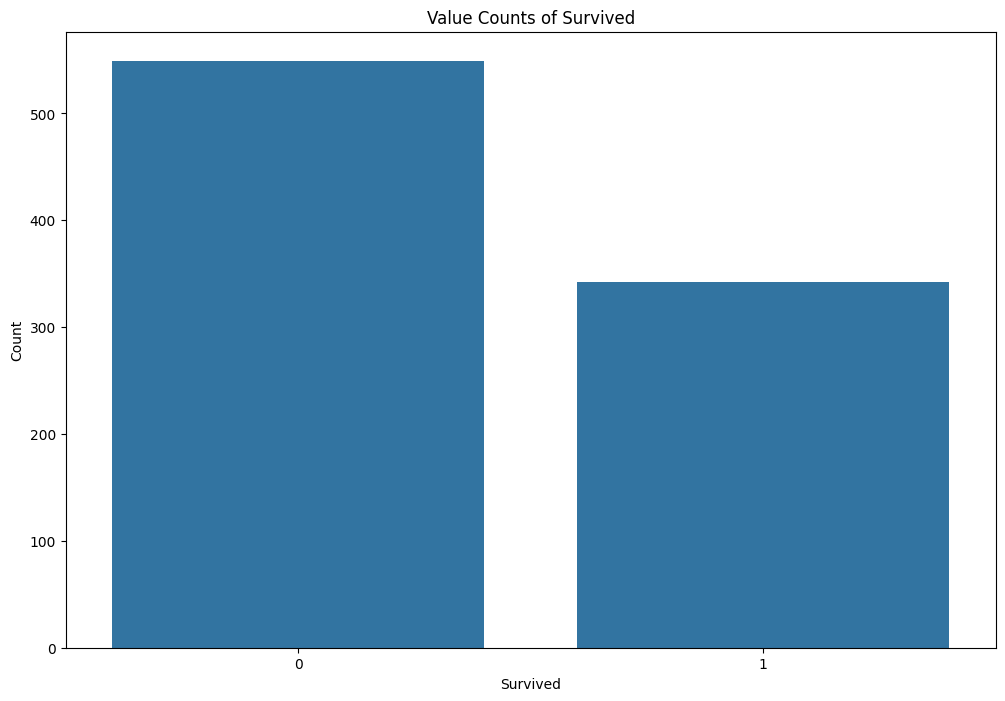

In [17]:
plt.figure(figsize=(12, 8))

sns.barplot(x = df['Survived'].value_counts().index, y = df['Survived'].value_counts())
plt.title('Value Counts of Survived')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

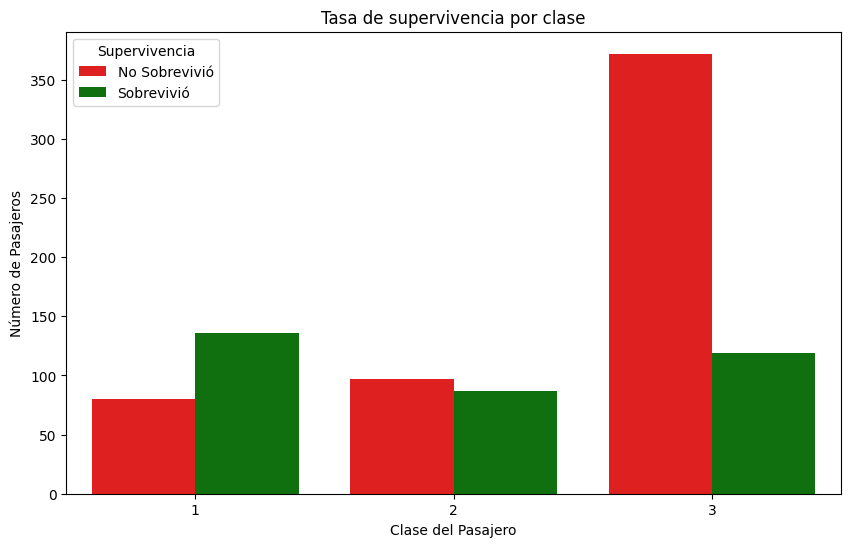

In [18]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Pclass', hue='Survived', data=df, palette=['red', 'green'])
plt.title('Tasa de supervivencia por clase')
plt.xlabel('Clase del Pasajero')
plt.ylabel('Número de Pasajeros')
plt.legend(title='Supervivencia', labels=['No Sobrevivió', 'Sobrevivió'])
plt.show()

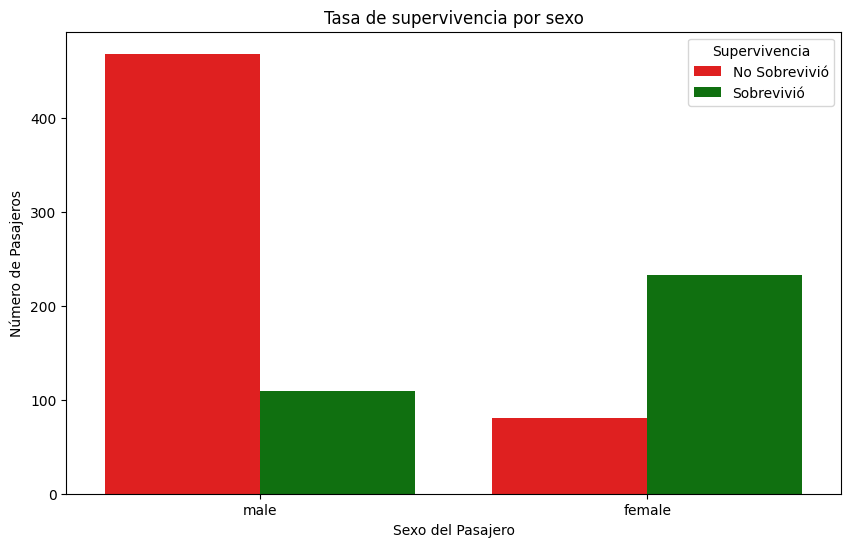

In [19]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Sex', hue='Survived', data=df, palette=['red', 'green'])
plt.title('Tasa de supervivencia por sexo')
plt.xlabel('Sexo del Pasajero')
plt.ylabel('Número de Pasajeros')
plt.legend(title='Supervivencia', labels=['No Sobrevivió', 'Sobrevivió'])
plt.show()

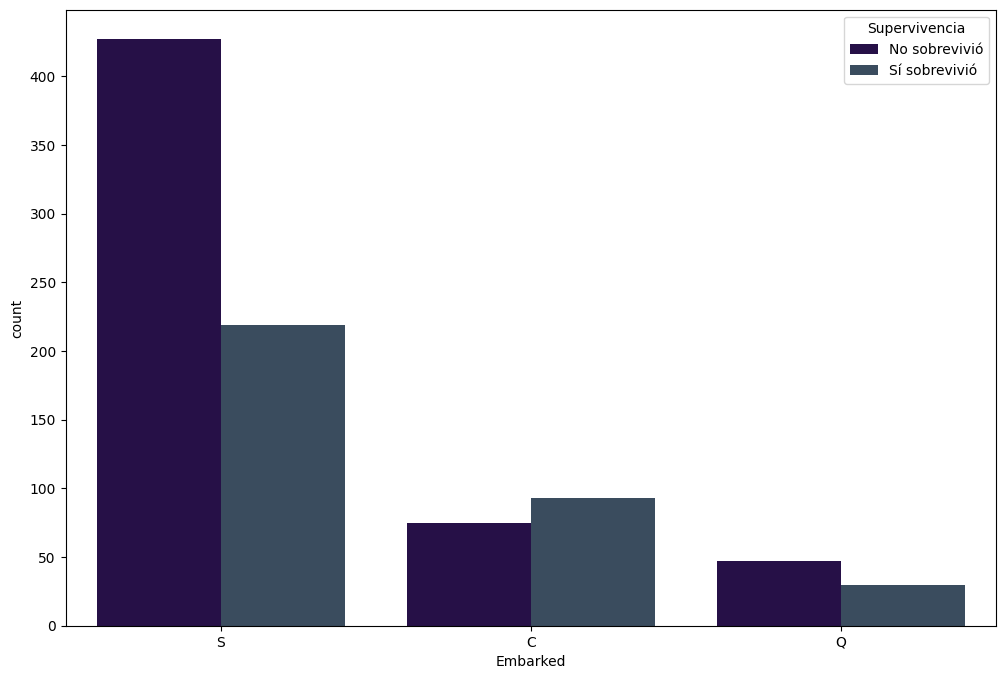

In [20]:
plt.figure(figsize = (12, 8))

# colores para cada una de las clases
color = ['#240750', '#344C64']

sns.countplot(df, x = 'Embarked', hue = 'Survived', palette=color) 
plt.legend(title = 'Supervivencia', labels = ['No sobrevivió', 'Sí sobrevivió'])
plt.show()

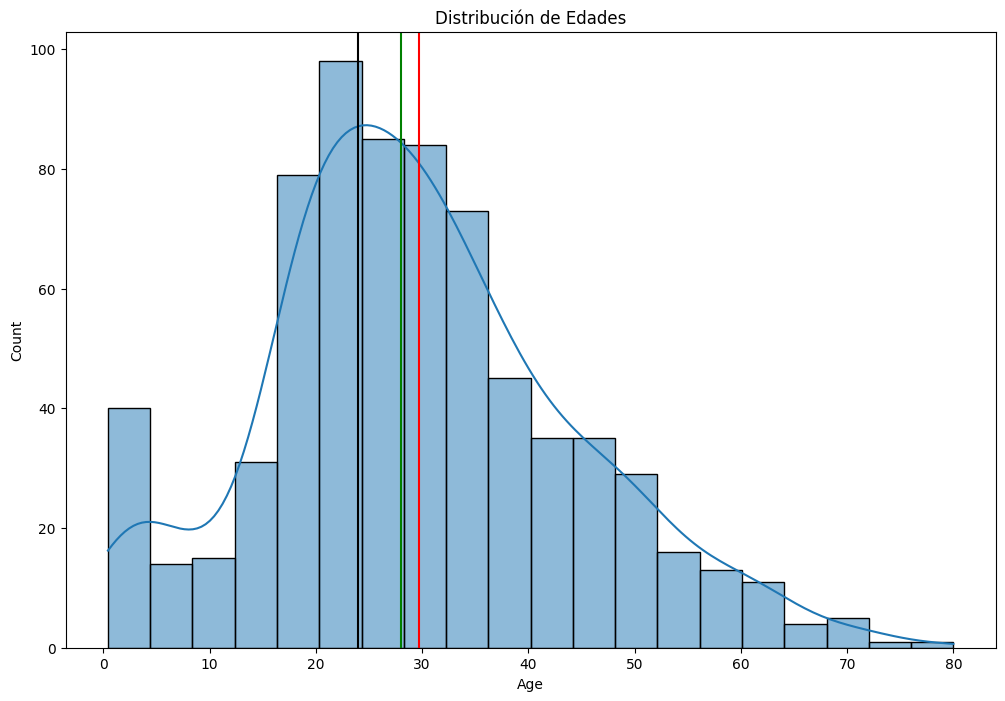

Media: 29.69911764705882
Mediana: 28.0
Moda: 24.0


In [23]:
plt.figure(figsize = (12, 8))

sns.histplot(df, x = 'Age', kde = True)
plt.title('Distribución de Edades')
plt.axvline(df['Age'].mean(), color = 'red')
plt.axvline(df['Age'].median(), color = 'green')
plt.axvline(df['Age'].mode()[0], color = 'black')
plt.show()

# Print the results
print(f"Media: {df['Age'].mean()}")
print(f"Mediana: {df['Age'].median()}")
print(f"Moda: {df['Age'].mode()[0]}")

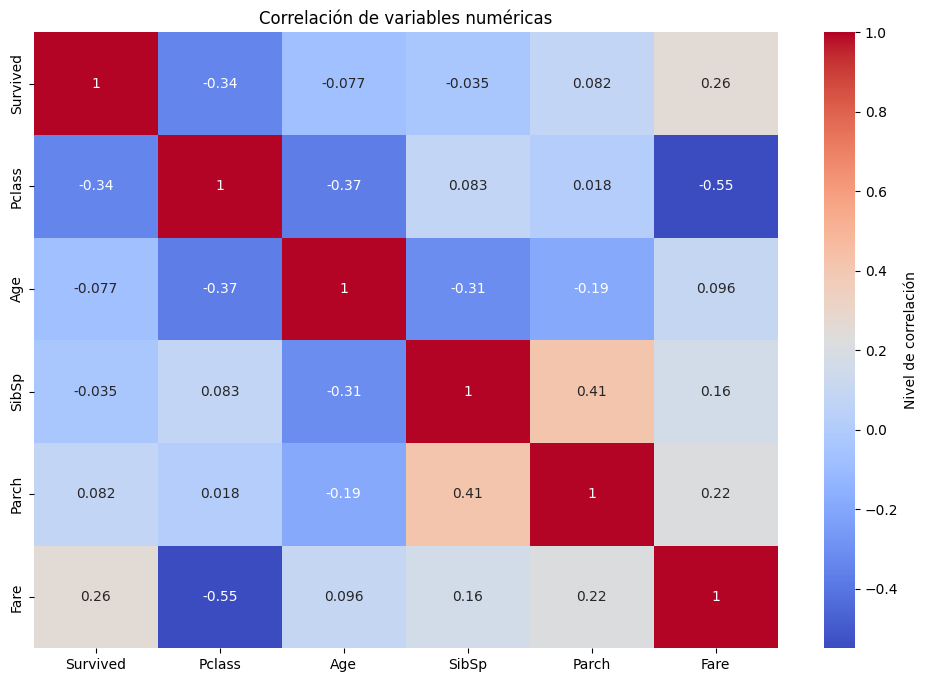

In [22]:
plt.figure(figsize = (12, 8))
sns.heatmap(df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].corr(), 
            annot=True, 
            cbar=True,  # Activar la barra de colores
            cmap='coolwarm',  # Cambiar la paleta de colores
            cbar_kws={'label': 'Nivel de correlación'})  # Etiqueta para la barra de colores
plt.title('Correlación de variables numéricas')
plt.show()

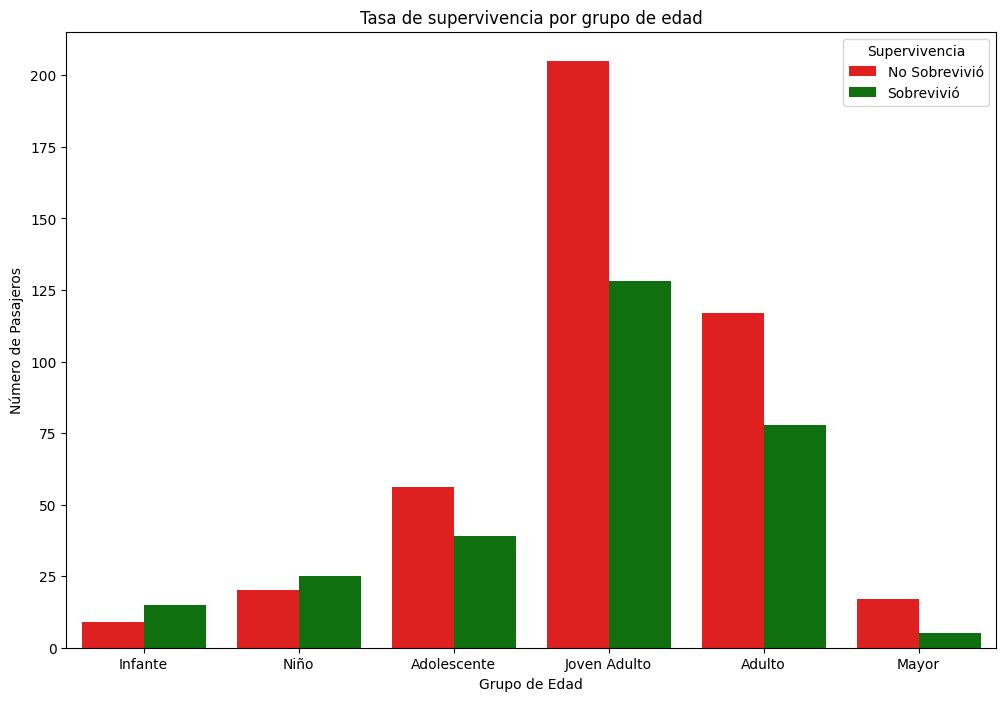

In [24]:
# Definir los rangos de edad para las categorías
bins = [0, 3, 13, 20, 36, 61, float('inf')]
labels = ['Infante', 'Niño', 'Adolescente', 'Joven Adulto', 'Adulto', 'Mayor']

# Crear una nueva columna con las categorías de edad
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

# Crear la gráfica de barras
plt.figure(figsize=(12, 8))
sns.countplot(x='Age_Group', hue='Survived', data=df, palette=['red', 'green'])
plt.title('Tasa de supervivencia por grupo de edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Número de Pasajeros')
plt.legend(title='Supervivencia', labels=['No Sobrevivió', 'Sobrevivió'])
plt.show()

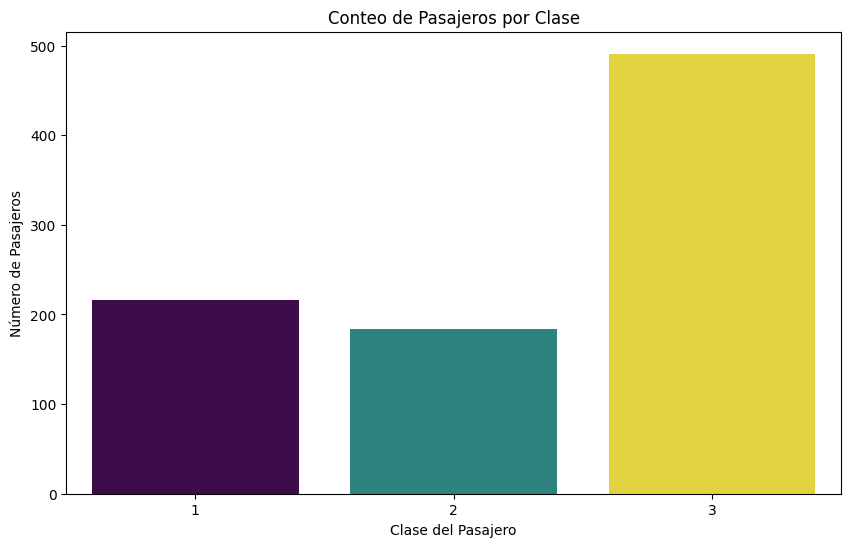

In [26]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Pclass', data=df, hue='Pclass', palette='viridis', legend=False)
plt.title('Conteo de Pasajeros por Clase')
plt.xlabel('Clase del Pasajero')
plt.ylabel('Número de Pasajeros')
plt.show()

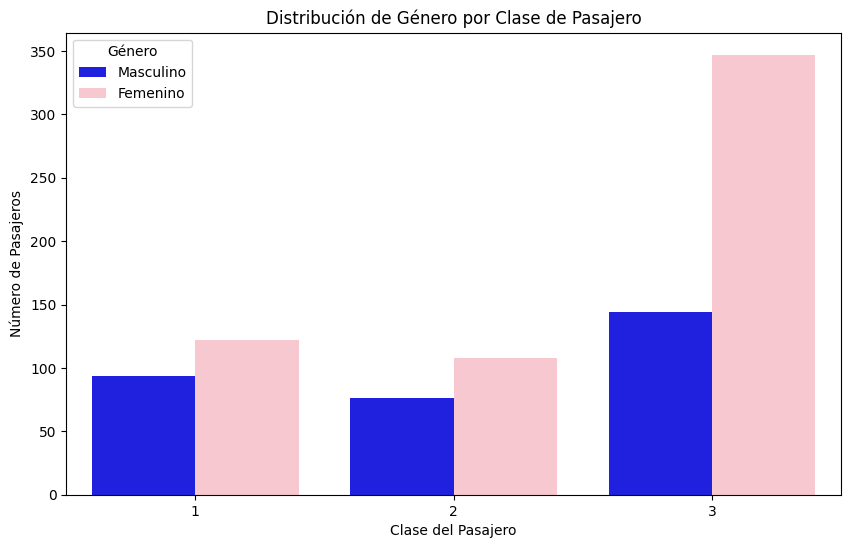

In [27]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Pclass', hue='Sex', data=df, palette=['blue', 'pink'])
plt.title('Distribución de Género por Clase de Pasajero')
plt.xlabel('Clase del Pasajero')
plt.ylabel('Número de Pasajeros')
plt.legend(title='Género', labels=['Masculino', 'Femenino'])
plt.show()

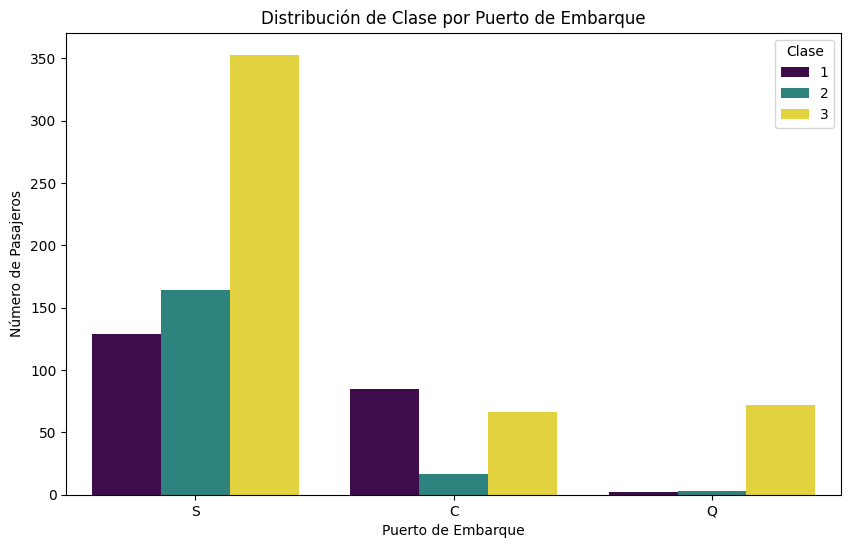

In [28]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Embarked', hue='Pclass', data=df, palette='viridis')
plt.title('Distribución de Clase por Puerto de Embarque')
plt.xlabel('Puerto de Embarque')
plt.ylabel('Número de Pasajeros')
plt.legend(title='Clase')
plt.show()

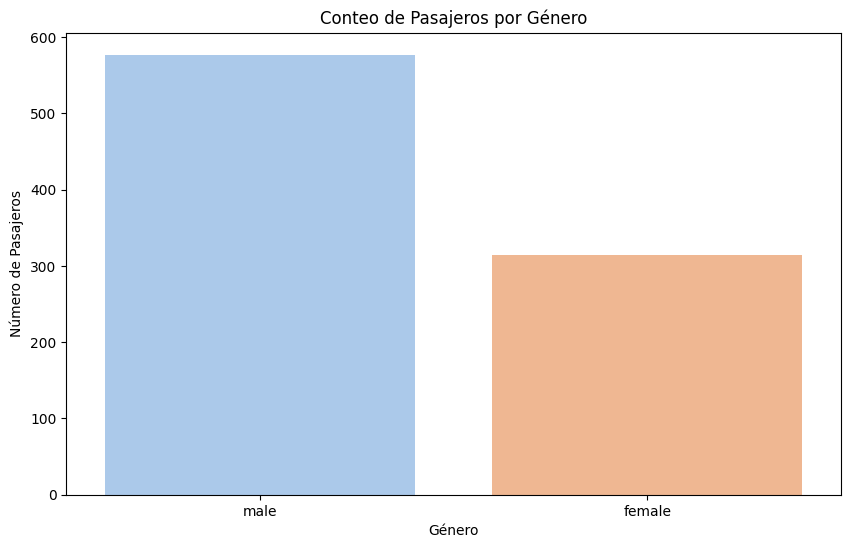

In [30]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Sex', data=df, hue='Sex', palette='pastel', legend=False)
plt.title('Conteo de Pasajeros por Género')
plt.xlabel('Género')
plt.ylabel('Número de Pasajeros')
plt.show()

In [31]:
print(f"Edad máxima: {df['Age'].max()}")
print(f"Edad mínima: {df['Age'].min()}")

Edad máxima: 80.0
Edad mínima: 0.42


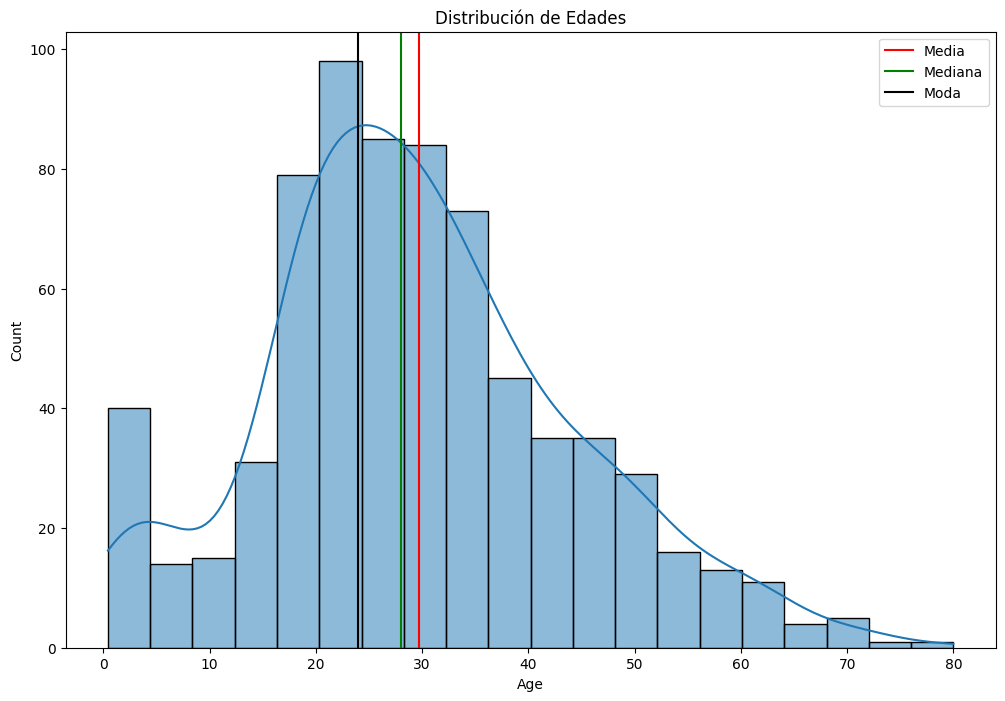

In [32]:
plt.figure(figsize=(12, 8))
sns.histplot(df, x='Age', kde=True)
plt.title('Distribución de Edades')
plt.axvline(df['Age'].mean(), color='red', label='Media')
plt.axvline(df['Age'].median(), color='green', label='Mediana')
plt.axvline(df['Age'].mode()[0], color='black', label='Moda')
plt.legend()
plt.show()

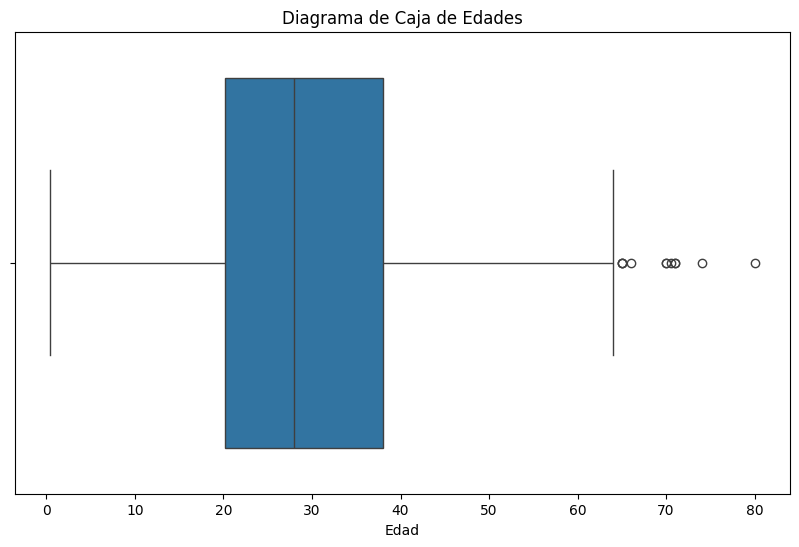

In [33]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Age'])
plt.title('Diagrama de Caja de Edades')
plt.xlabel('Edad')
plt.show()

In [34]:
print(f"Tarifa máxima: {df['Fare'].max()}")
print(f"Tarifa mínima: {df['Fare'].min()}")

Tarifa máxima: 512.3292
Tarifa mínima: 0.0


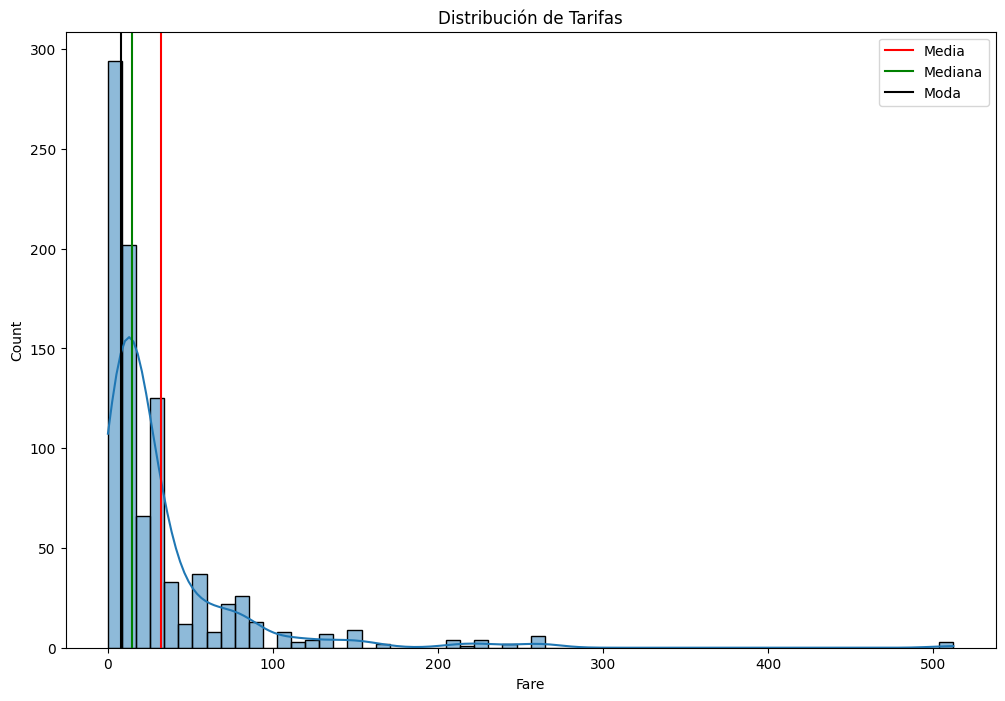

In [35]:
plt.figure(figsize=(12, 8))
sns.histplot(df, x='Fare', kde=True)
plt.title('Distribución de Tarifas')
plt.axvline(df['Fare'].mean(), color='red', label='Media')
plt.axvline(df['Fare'].median(), color='green', label='Mediana')
plt.axvline(df['Fare'].mode()[0], color='black', label='Moda')
plt.legend()
plt.show()

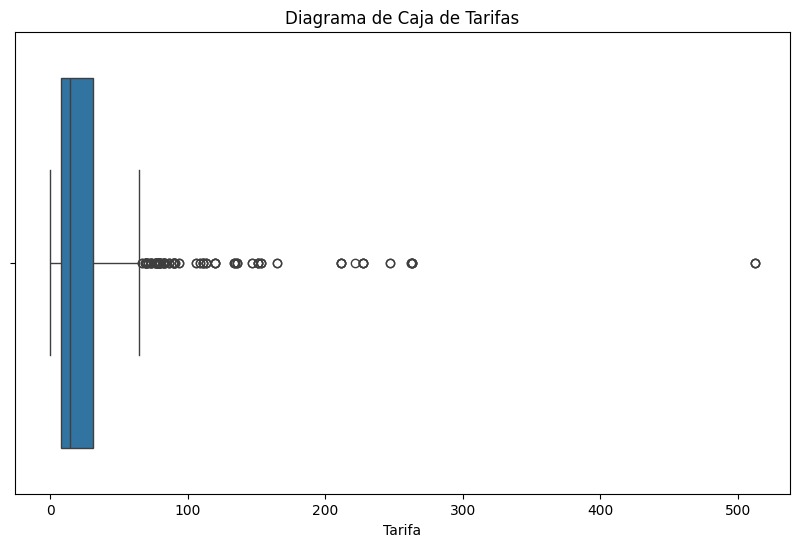

In [36]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Fare'])
plt.title('Diagrama de Caja de Tarifas')
plt.xlabel('Tarifa')
plt.show()

In [37]:
passengers_zero_fare = df[df['Fare'] == 0]
print(passengers_zero_fare)

     Survived  Pclass   Sex   Age  SibSp  Parch  Fare Embarked     Age_Group
179         0       3  male  36.0      0      0   0.0        S        Adulto
263         0       1  male  40.0      0      0   0.0        S        Adulto
271         1       3  male  25.0      0      0   0.0        S  Joven Adulto
277         0       2  male   NaN      0      0   0.0        S           NaN
302         0       3  male  19.0      0      0   0.0        S   Adolescente
413         0       2  male   NaN      0      0   0.0        S           NaN
466         0       2  male   NaN      0      0   0.0        S           NaN
481         0       2  male   NaN      0      0   0.0        S           NaN
597         0       3  male  49.0      0      0   0.0        S        Adulto
633         0       1  male   NaN      0      0   0.0        S           NaN
674         0       2  male   NaN      0      0   0.0        S           NaN
732         0       2  male   NaN      0      0   0.0        S           NaN

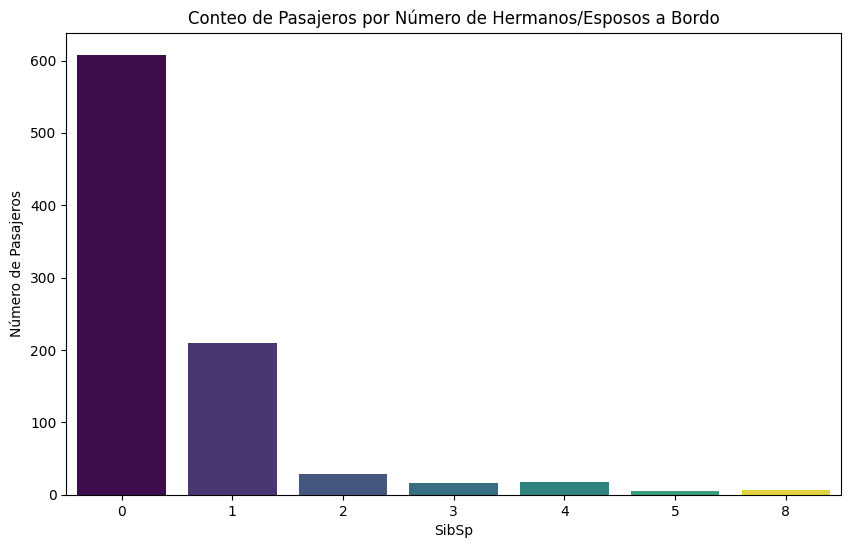

In [38]:
plt.figure(figsize=(10, 6))
sns.countplot(x='SibSp', data=df, palette='viridis', hue='SibSp', legend=False)
plt.title('Conteo de Pasajeros por Número de Hermanos/Esposos a Bordo')
plt.xlabel('SibSp')
plt.ylabel('Número de Pasajeros')
plt.show()

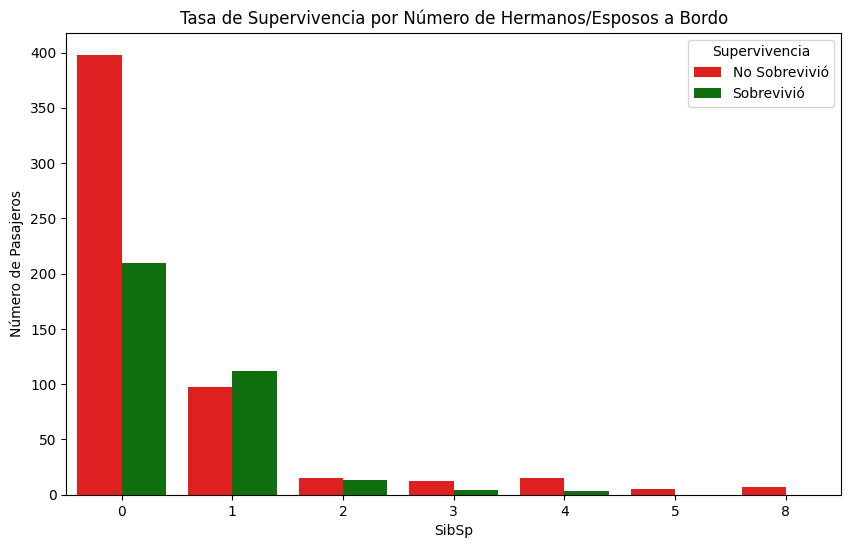

In [39]:
plt.figure(figsize=(10, 6))
sns.countplot(x='SibSp', hue='Survived', data=df, palette=['red', 'green'])
plt.title('Tasa de Supervivencia por Número de Hermanos/Esposos a Bordo')
plt.xlabel('SibSp')
plt.ylabel('Número de Pasajeros')
plt.legend(title='Supervivencia', labels=['No Sobrevivió', 'Sobrevivió'])
plt.show()

In [40]:
survival_percentage = df.groupby('SibSp')['Survived'].mean() * 100
print(survival_percentage)

SibSp
0    34.539474
1    53.588517
2    46.428571
3    25.000000
4    16.666667
5     0.000000
8     0.000000
Name: Survived, dtype: float64


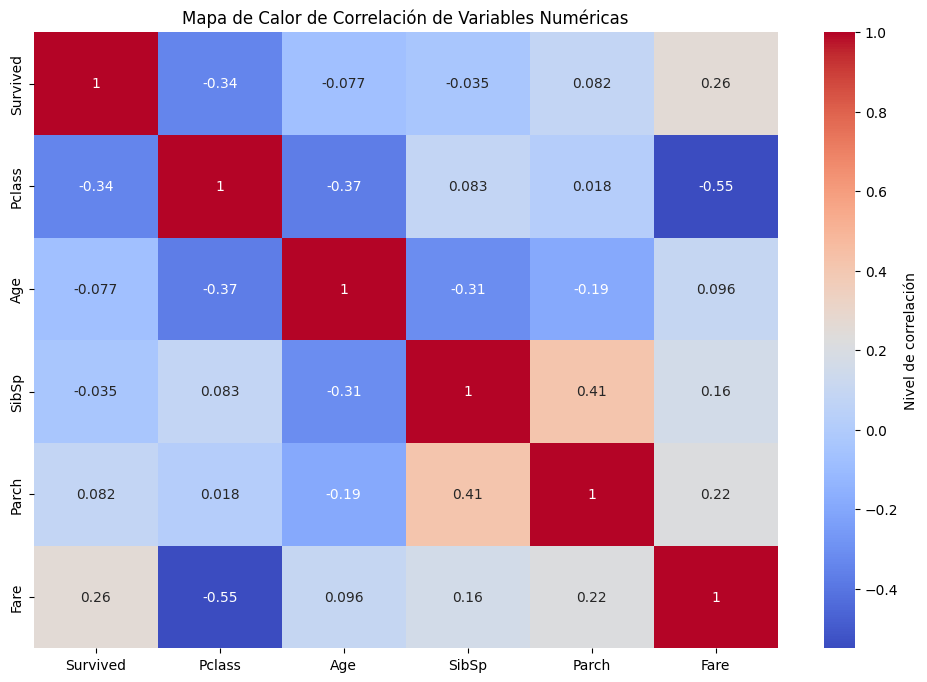

In [41]:
plt.figure(figsize=(12, 8))
sns.heatmap(df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].corr(), 
            annot=True, 
            cbar=True,  
            cmap='coolwarm',  
            cbar_kws={'label': 'Nivel de correlación'})
plt.title('Mapa de Calor de Correlación de Variables Numéricas')
plt.show()